In [1]:
import numpy as np
from oneargopy.OneArgo import Argo
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.cm as cm # new package for the colorbar
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import LogLocator, FormatStrFormatter
from matplotlib.colors import LogNorm
import gsw
from tqdm import tqdm
import matplotlib.image as mpimg
import earthaccess
import h5netcdf
import seaborn as sns
import xarray as xr
from matplotlib.patches import Rectangle
import dask
import contourpy

from importlib import reload
import SO_tools as tools; reload(tools)

/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'SO_tools' from '/Users/lilah/Documents/IBIS_Project/SO_tools.py'>

In [2]:
df_new = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_Summer/newest_bgc_profiles_ext_alltime.csv')
# df_new = pd.read_csv('/Users/steviewalker/Documents/IBIS_Project/Data_Summer/new_bgc_profiles_BR_extended_area_all_time.csv') # for stevie


/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_61957/3273616132.py:1: DtypeWarning: Columns (0: season) have mixed types. Specify dtype option on import or set low_memory=False.
  df_new = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_Summer/newest_bgc_profiles_ext_alltime.csv')


## Function for stratification depth profiles

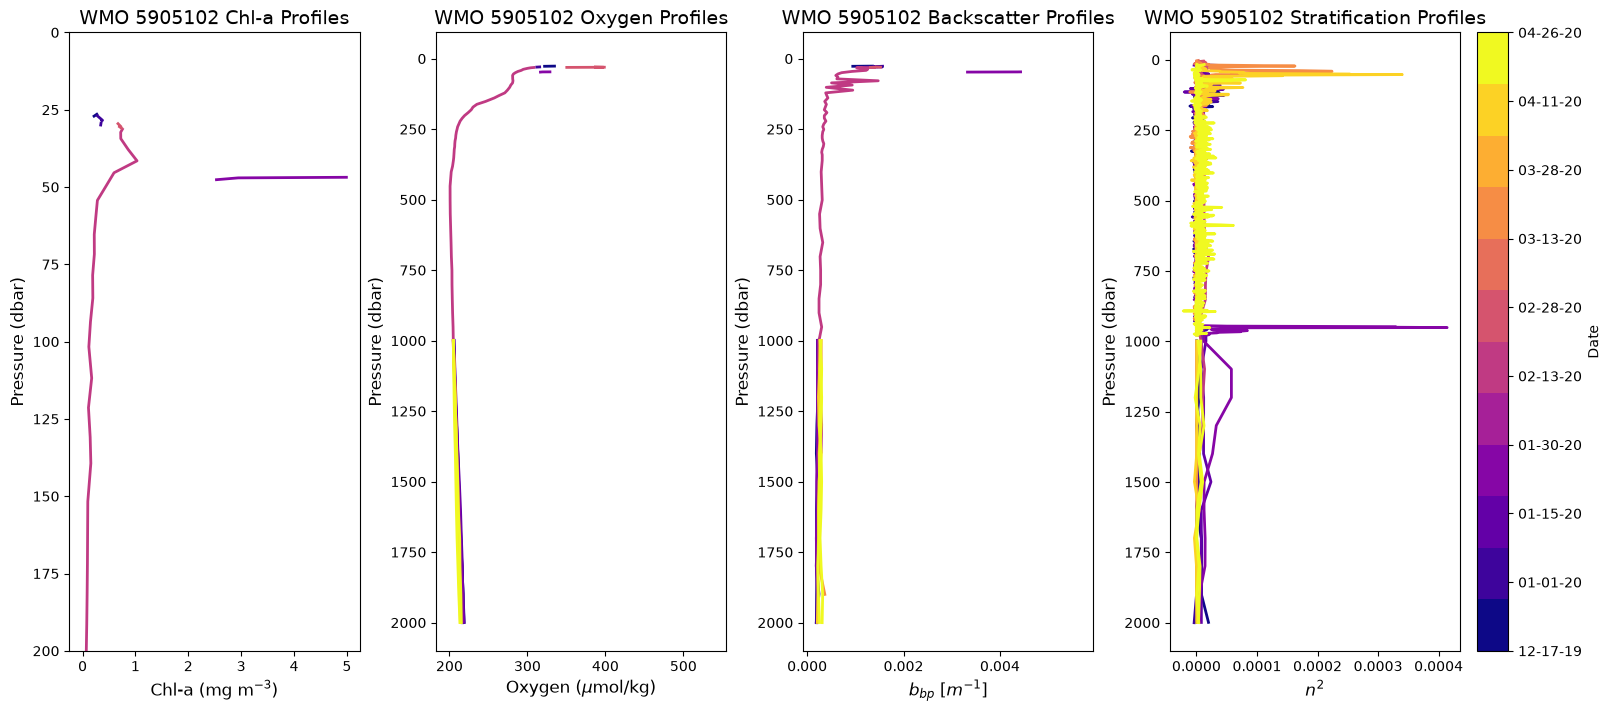

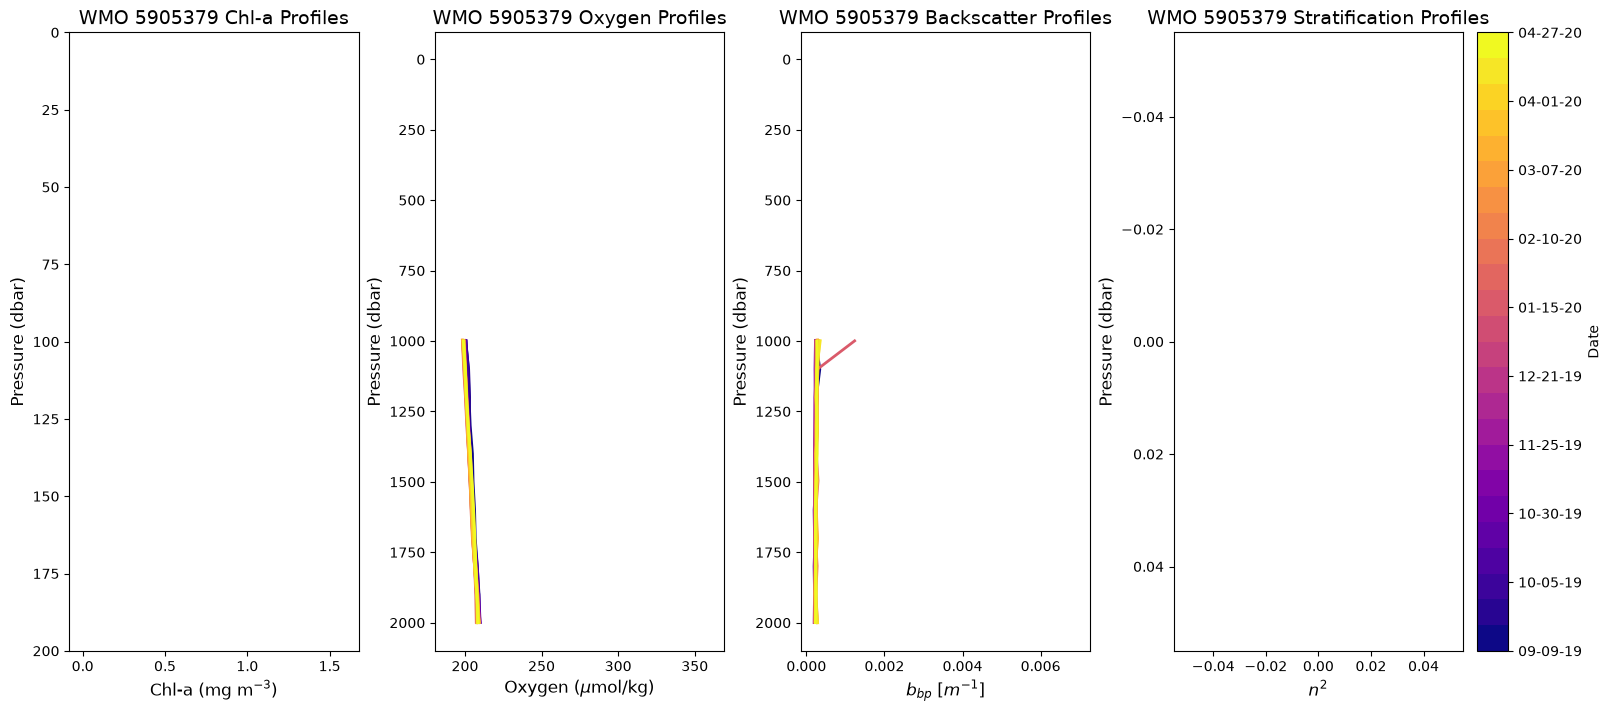

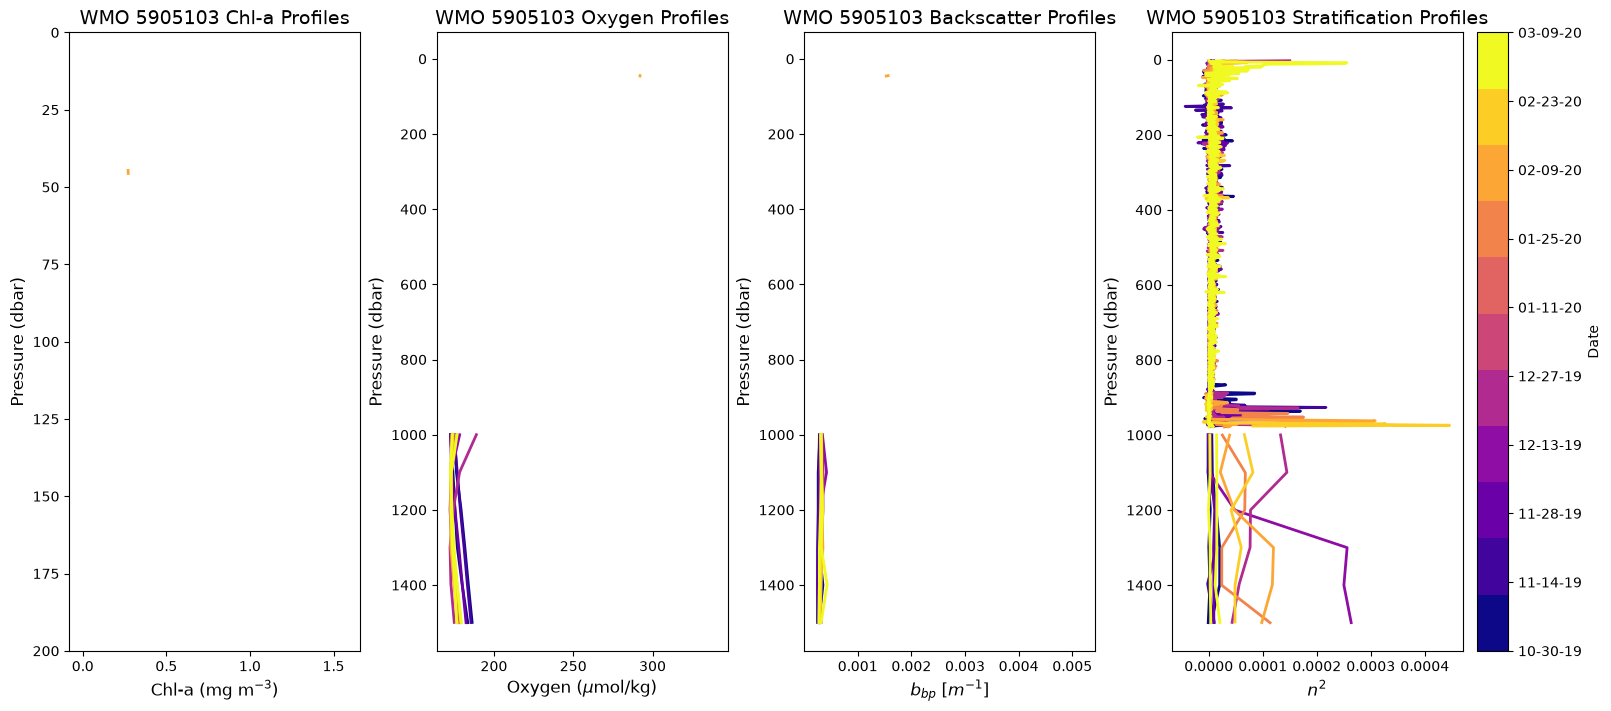

In [44]:
# def n_squared(WMOID, cycle

              #  FUNCTION FOR DEPTH PROFILES

def prof_yr(df, season, WMOID):
    
    #subset to productive months
    df = df[df['season'].isin([season])]
    df = df[df['WMOID'].isin([WMOID])]
    
    df['DATE'] = pd.to_datetime(df['DATE'])
    date_nums = mdates.date2num(df['DATE'])
    
    # Shared normalization and colormap
    norm = mcolors.Normalize(vmin=date_nums.min(), vmax=date_nums.max())
    cmap = plt.get_cmap('plasma', len(df['DATE'].unique()))
    
    # Create figure and axis
    fig = plt.figure(figsize=(16,7), layout='constrained')
    
    # Chlorophyll profile -----------------------------------------------------------------
    ax = fig.add_subplot(141)
    for cycle, group in df.groupby('CYCLE_NUMBER'):
        date_val = mdates.date2num(group['DATE'].iloc[0])
        color = cmap(norm(date_val))
        ax.plot(group['CHLA_ADJUSTED'], group['PRES_ADJUSTED'], color=color, lw=2)
    
    # ax.set_xlim(0, 7)
    ax.set_ylim(0, 200)
    ax.invert_yaxis()
    ax.set_xlabel('Chl-a (mg m$^{-3}$)', fontsize=12)
    ax.set_ylabel('Pressure (dbar)', fontsize=12)
    ax.set_title(f'WMO {str(WMOID)} Chl-a Profiles', fontsize=14)

    # ADD ADDITIONAL VARIABLES HERE (nitrate, oxygen, bbp, nitrate, t, s, etc) ---------------
    # Oxygen profile ------------------------------------------------------------------------
    ax = fig.add_subplot(142)
    for cycle, group in df.groupby('CYCLE_NUMBER'):
        date_val = mdates.date2num(group['DATE'].iloc[0])
        color = cmap(norm(date_val))
        ax.plot(group['DOXY_ADJUSTED'], group['PRES_ADJUSTED'], color=color, lw=2)

    # ax.set_ylim(0, 1000)
    ax.invert_yaxis()
    ax.set_xlabel(r'Oxygen ($\mu\text{mol/kg}$)', fontsize=12)
    ax.set_ylabel('Pressure (dbar)', fontsize=12)
    ax.set_title(f'WMO {str(WMOID)} Oxygen Profiles', fontsize=14)

    # BBP profile ----------------------------------------------------------------------------
    ax = fig.add_subplot(143)
    for cycle, group in df.groupby('CYCLE_NUMBER'):
        date_val = mdates.date2num(group['DATE'].iloc[0])
        color = cmap(norm(date_val))
        ax.plot(group['BBP700_ADJUSTED'], group['PRES_ADJUSTED'], color=color, lw=2)

    # ax.set_ylim(0, 1000)
    ax.invert_yaxis()
    ax.set_xlabel(r'$b_{bp}$ [$m^{-1}$]', fontsize=12)
    ax.set_ylabel('Pressure (dbar)', fontsize=12)
    ax.set_title(f'WMO {str(WMOID)} Backscatter Profiles', fontsize=14)

    # Stratification profile ---------------------------------------------------------------------
    ax = fig.add_subplot(144)
    for cycle, group in df.groupby('CYCLE_NUMBER'):
        date_val = mdates.date2num(group['DATE'].iloc[0])
        color = cmap(norm(date_val))
        ax.plot(group['nsq'], group['PRES_ADJUSTED'], color=color, lw=2)

    # ax.set_ylim(0, 1000)
    ax.invert_yaxis()
    ax.set_xlabel(r'$n^{2}$', fontsize=12)
    ax.set_ylabel('Pressure (dbar)', fontsize=12)
    ax.set_title(f'WMO {str(WMOID)} Stratification Profiles', fontsize=14)
    
    #add colorbar
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical', label='Date')
    
    tick_locs = np.linspace(date_nums.min(), date_nums.max(), 10)
    cbar.set_ticks(tick_locs)
    cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%m-%d-%y'))
    plt.show()

    #save profile
    # fig.savefig(f'/Users/lilah/Documents/IBIS_Project/Figures/float_trajectories_depth{season}.png') #uncomment for lilah
    # fig.savefig(f'/Users/steviewalker/Documents/IBIS_Project/Figures/chla_profile_timeseries_WMO{WMOID}_{season}.png') #uncomment for stevie

prof_yr(df = df_new, season = '2019-2020', WMOID = 5905102)
prof_yr(df = df_new, season = '2019-2020', WMOID = 5905379)
prof_yr(df = df_new, season = '2019-2020', WMOID = 5905103)


In [40]:
df_id = df_new[df_new['WMOID'] == 5905100]
df_id

,Unnamed: 0.1,Unnamed: 0,WMOID,CYCLE_NUMBER,DIRECTION,DATE,DATE_QC,LATITUDE,LONGITUDE,POSITION_QC,...,DOWNWELLING_PAR_ADJUSTED_ERROR,year,month,season,SA,CT,rho,sigma0,nsq,MLP
691956,691956,692936,5905100,1,A,2017-04-18 12:00:49.001287+00:00,1,-65.510,171.978,1,...,NaN,2017,4,2016-2017,34.237315,0.123812,1027.377728,27.355896,7.272865e-08,100.480000
691957,691957,692937,5905100,1,A,2017-04-18 12:00:49.001287+00:00,1,-65.510,171.978,1,...,NaN,2017,4,2016-2017,34.237314,0.124739,1027.387688,27.355845,7.121780e-08,100.480000
691958,691958,692938,5905100,1,A,2017-04-18 12:00:49.001287+00:00,1,-65.510,171.978,1,...,NaN,2017,4,2016-2017,34.237918,0.123501,1027.393101,27.356396,3.093085e-08,100.480000
691959,691959,692939,5905100,1,A,2017-04-18 12:00:49.001287+00:00,1,-65.510,171.978,1,...,NaN,2017,4,2016-2017,34.238319,0.122676,1027.396707,27.356761,4.802576e-07,100.480000
691960,691960,692940,5905100,1,A,2017-04-18 12:00:49.001287+00:00,1,-65.510,171.978,1,...,NaN,2017,4,2016-2017,34.238311,0.123342,1027.403862,27.356719,4.418556e-07,100.480000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
734692,734692,735672,5905100,77,A,2019-05-22 14:58:23.001586+00:00,1,-65.441,162.491,1,...,NaN,2019,5,2019,34.866376,0.425743,1035.313551,27.843282,6.101186e-08,67.450005
734693,734693,735673,5905100,77,A,2019-05-22 14:58:23.001586+00:00,1,-65.441,162.491,1,...,NaN,2019,5,2019,34.864606,0.379080,1035.774818,27.844613,4.916725e-07,67.450005
734694,734694,735674,5905100,77,A,2019-05-22 14:58:23.001586+00:00,1,-65.441,162.491,1,...,NaN,2019,5,2019,34.864133,0.339785,1036.235575,27.846526,3.427100e-07,67.450005
734695,734695,735675,5905100,77,A,2019-05-22 14:58:23.001586+00:00,1,-65.441,162.491,1,...,NaN,2019,5,2019,34.863132,0.302975,1036.692519,27.847853,2.552830e-07,67.450005


In [41]:
df_id['nsq']

691956    7.272865e-08
691957    7.121780e-08
691958    3.093085e-08
691959    4.802576e-07
691960    4.418556e-07
              ...     
734692    6.101186e-08
734693    4.916725e-07
734694    3.427100e-07
734695    2.552830e-07
734696    2.521900e-07
Name: nsq, Length: 42741, dtype: float64

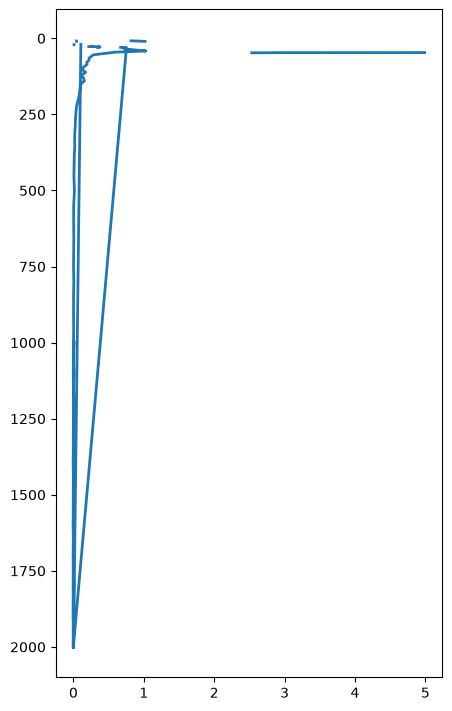

In [28]:
fig = plt.figure(figsize=(16,7), layout='constrained')
ax = fig.add_subplot(141)

ax.plot(df_id['CHLA_ADJUSTED'], df_id['PRES_ADJUSTED'], lw=2)

# ax.set_xlim(0, 7)
# ax.set_ylim(0, 200)
ax.invert_yaxis()